In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

project_path = "/content/drive/MyDrive/Earthquake_GNN"

os.makedirs(project_path, exist_ok=True)

### Step 1: Install `kagglehub` and Download the Dataset

We will use `kagglehub` to directly download the dataset from Kaggle. This simplifies the process by handling authentication implicitly if you're using a Colab environment or have Kaggle credentials set up elsewhere. If you encounter authentication issues, you might need to revert to the previous method or ensure your Colab environment is linked to a Google account associated with Kaggle.

The dataset identifier for 'The Ultimate Earthquake Dataset From 1990-2023' is `alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023`.

In [5]:
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Dataset identifier
dataset_id = 'alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023'

# Download the dataset
# kagglehub typically downloads to a cached directory and returns its path
print(f"Downloading dataset: {dataset_id}")
download_path = kagglehub.dataset_download(dataset_id)

print(f"Dataset downloaded to: {download_path}")

# List files in the downloaded directory to identify the CSV
downloaded_files = os.listdir(download_path)
print("Files in downloaded directory:", downloaded_files)

# Corrected: The main data file is 'Eartquakes-1990-2023.csv'
# Adjust this if the filename is different based on the `downloaded_files` output
csv_file_name = 'Eartquakes-1990-2023.csv'
csv_file_path = os.path.join(download_path, csv_file_name)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print("\nFirst 5 rows of the DataFrame:")
display(df.head())

100%|██████████| 116M/116M [00:03<00:00, 33.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023/versions/4
Files in downloaded directory: ['Eartquakes-1990-2023.csv']

First 5 rows of the DataFrame:


,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


### DATA PREPROCESSING

In [6]:
negative_count = (df['magnitudo'] < 0).sum()
print("Number of rows with negative magnitudo:", negative_count)


Number of rows with negative magnitudo: 88715


In [7]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)

time            0
place           0
status          0
tsunami         0
significance    0
data_type       0
magnitudo       0
state           0
longitude       0
latitude        0
depth           0
date            0
dtype: int64
time            0.0
place           0.0
status          0.0
tsunami         0.0
significance    0.0
data_type       0.0
magnitudo       0.0
state           0.0
longitude       0.0
latitude        0.0
depth           0.0
date            0.0
dtype: float64


In [8]:
print("Total rows:", len(df))


Total rows: 3445751


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 16869


In [10]:
neg_mag = (df['magnitudo'] < 0).sum()
print("Rows with negative magnitude:", neg_mag)

Rows with negative magnitude: 88715


In [11]:
df = df.drop_duplicates()
df = df[df['magnitudo'] >= 0]

In [12]:
print("Total rows:", len(df))

Total rows: 3340460


In [13]:


#Convert the time column
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

#Create a new time difference feature
df['time_diff'] = df['time'].diff().dt.total_seconds()
df['time_diff'] = df['time_diff'].fillna(0)

print("Cleaned dataset rows:", df.shape[0])





Cleaned dataset rows: 3340460


In [14]:
#Add new feature distance the previous
#from geopy.distance import geodesic

#distances = [0]

#for i in range(1, len(df)):

 #   coord1 = (df.iloc[i-1]['latitude_raw'], df.iloc[i-1]['longitude_raw'])
#  coord2 = (df.iloc[i]['latitude_raw'], df.iloc[i]['longitude_raw'])

#    d = geodesic(coord1, coord2).km
#    distances.append(d)

#df['dist_prev'] = distances

# Using Haversine Distance as it is faster
import numpy as np

# convert lat/lon to radians
lat1 = np.radians(df['latitude'].shift(1))
lon1 = np.radians(df['longitude'].shift(1))

lat2 = np.radians(df['latitude'])
lon2 = np.radians(df['longitude'])

# compute differences
dlat = lat2 - lat1
dlon = lon2 - lon1

# haversine formula
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

earth_radius = 6371  # km

df['dist_prev'] = earth_radius * c

# first row will be NaN because there is no previous event
df['dist_prev'] = df['dist_prev'].fillna(0)

In [15]:
df = df.drop(columns=['date'])
display(df.head())

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,time_diff,dist_prev
0,1970-01-01 00:10:31.153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,0.000000,0.000000
1,1970-01-01 00:10:31.153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,0.000137,4735.768169
2,1970-01-01 00:10:31.154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,0.000592,3791.037585
3,1970-01-01 00:10:31.155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,0.001429,368.922544
4,1970-01-01 00:10:31.155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,0.000312,346.832219


NORMALIZING

In [16]:
# Save raw values for later graph construction
df['latitude_raw'] = df['latitude']
df['longitude_raw'] = df['longitude']
df['depth_raw'] = df['depth']
df['magnitudo_raw'] = df['magnitudo']
df['dist_prev_raw'] = df['dist_prev']
df['time_diff_raw'] = df['time_diff']

features = [
    'latitude',
    'longitude',
    'depth',
    'magnitudo',
    'dist_prev',
    'time_diff',
    'significance'
]


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[features] = scaler.fit_transform(df[features])

In [17]:
df.to_csv("/content/drive/MyDrive/Earthquake_GNN/earthquake_preprocessed.csv", index=False)

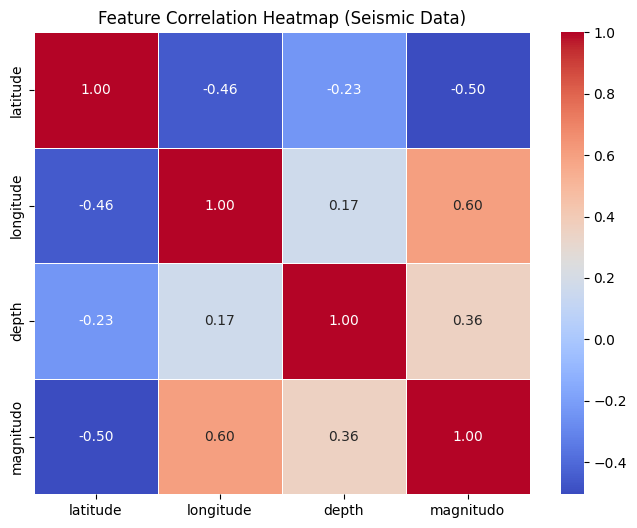

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only required columns
cols = ['latitude', 'longitude', 'depth', 'magnitudo']
data = df[cols]

# Correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Heatmap (Seismic Data)")
plt.show()


NameError: name 'x' is not defined

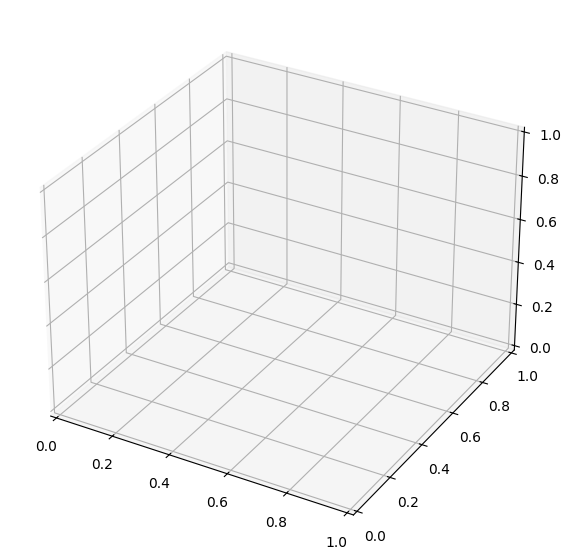

In [19]:
# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with fixed color scale 0 to 10
scatter = ax.scatter(
    x, y, z,
    c=z,
    cmap='RdYlGn_r',   # green to red
    s=20,
    vmin=0,
    vmax=10
)

# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Magnitude")
ax.set_title("3D Spatial Distribution of Earthquake Magnitudes")

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, label="Magnitude")
cbar.set_ticks(range(0, 11))  # 0 to 10 ticks

plt.show()

### GNN Implementation

In [20]:
# Use the already-correct 'date' column when available.
# Fallback to epoch milliseconds in 'time' if needed.
if 'date' in df.columns:
    df['time'] = pd.to_datetime(df['date'], utc=True)
else:
    df['time'] = pd.to_datetime(df['time'], unit='ms', utc=True)

df = df.sort_values('time').reset_index(drop=True)

# Recompute temporal feature after correcting timestamps
df['time_diff'] = df['time'].diff().dt.total_seconds().fillna(0)

# Optional: use log-scaled variants for heavy-tailed features
df['time_diff_log'] = np.log1p(df['time_diff'])
df['dist_prev_log'] = np.log1p(df['dist_prev'])

print('Corrected time range:')
print(df['time'].min(), '->', df['time'].max())
print('Rows:', len(df))
display(df[['time', 'latitude', 'longitude', 'depth', 'magnitudo', 'time_diff', 'dist_prev']].head())


Corrected time range:
1970-01-01 00:10:31.153353990+00:00 -> 1970-01-01 00:28:10.628937884+00:00
Rows: 3340460


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,time,latitude,longitude,depth,magnitudo,time_diff,dist_prev
0,1970-01-01 00:10:31.153353990+00:00,1.185133,-0.631007,0.122397,0.534712,0.000000,-1.009680
1,1970-01-01 00:10:31.153491210+00:00,-0.872746,-0.702263,-0.301369,-0.337446,0.000137,0.136114
2,1970-01-01 00:10:31.154083450+00:00,0.073566,-0.285688,-0.362010,-0.577490,0.000592,-0.092458
3,1970-01-01 00:10:31.155512130+00:00,0.017444,-0.234785,-0.430562,-0.681509,0.001429,-0.920421
4,1970-01-01 00:10:31.155824490+00:00,-0.133859,-0.235912,-0.129502,0.894777,0.000312,-0.925766


This section fixes the timestamp issue, validates graph-readiness, and creates the requested temporal 85% / 7.5% / 7.5% split.

In [21]:
# Temporal 85 / 7.5 / 7.5 split
n = len(df)
train_end = int(n * 0.85)
val_end = train_end + int(n * 0.075)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print('Total:', n)
print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))
print('Check total:', len(train_df) + len(val_df) + len(test_df))


Total: 3340460
Train: 2839391
Validation: 250534
Test: 250535
Check total: 3340460


In [22]:
# Save splits
train_df.to_parquet('train_earthquake.parquet', index=False)
val_df.to_parquet('val_earthquake.parquet', index=False)
test_df.to_parquet('test_earthquake.parquet', index=False)

print('Saved:')
print('- train_earthquake.parquet')
print('- val_earthquake.parquet')
print('- test_earthquake.parquet')

Saved:
- train_earthquake.parquet
- val_earthquake.parquet
- test_earthquake.parquet


## Recommended Graph Input Format (PyTorch Geometric)

Each training sample should be a graph window with:
- nodes = earthquakes in the previous 90 days
- edges = causal pairs satisfying distance <= 100 km and time gap <= 90 days

Use:
- `x`: node feature matrix
- `edge_index`: directed edges
- `edge_attr`: edge features
- `y`: label


In [23]:
gnn_node_features = [
    'latitude',
    'longitude',
    'depth',
    'magnitudo',
    'significance',
    'time_diff_log',
    'dist_prev_log'
]


### GNN Imports:

- Implementing LSTM classifier
- Creating sequence windows
- Training baseline model
- Computing the following metrics:
  - Precision
  - Recall
  - F1
  - AUC-ROC
  - LTSS

In [25]:
!pip install -q torch torchvision torchaudio torch-geometric scikit-learn tqdm optuna
import os
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from tqdm.auto import tqdm

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [27]:
TARGET_COL = "label"
TIME_COL = "time"
LAT_COL = "latitude_raw" if "latitude_raw" in df.columns else "latitude"
LON_COL = "longitude_raw" if "longitude_raw" in df.columns else "longitude"
MAG_COL = "magnitudo_raw" if "magnitudo_raw" in df.columns else "magnitudo"
DEPTH_COL = "depth_raw" if "depth_raw" in df.columns else "depth"
DIST_PREV_COL = "dist_prev_raw" if "dist_prev_raw" in df.columns else "dist_prev"
TIME_DIFF_COL = "time_diff_raw" if "time_diff_raw" in df.columns else "time_diff"
SIG_COL = "significance" if "significance" in df.columns else None

BASE_FEATURES = [LAT_COL, LON_COL, DEPTH_COL, MAG_COL, DIST_PREV_COL, TIME_DIFF_COL]
if SIG_COL is not None:
    BASE_FEATURES.append(SIG_COL)
BASE_FEATURES = [c for c in BASE_FEATURES if c in df.columns]

SEQ_LEN = 32
BATCH_SIZE = 256
LSTM_HIDDEN = 128
LSTM_LAYERS = 2
LSTM_DROPOUT = 0.2
LSTM_LR = 1e-3
LSTM_EPOCHS = 10

GRAPH_LOOKBACK_DAYS = 90
SPATIAL_THRESHOLD_KM = 100.0
MAX_GRAPH_NODES = 128
GRAPH_BATCH_SIZE = 64
GAT_HIDDEN = 64
GAT_HEADS = 4
GAT_LAYERS = 2
TEMPORAL_EMBED_DIM = 16
TCN_CHANNELS = 64
GAT_DROPOUT = 0.2
GAT_LR = 1e-3
GAT_EPOCHS = 10

TUNE_TRIALS = 10

print("Base features:", BASE_FEATURES)

Base features: ['latitude_raw', 'longitude_raw', 'depth_raw', 'magnitudo_raw', 'dist_prev_raw', 'time_diff_raw', 'significance']


In [29]:
from pandas.api.types import (
    is_datetime64_any_dtype,
    is_numeric_dtype,
)

def ensure_datetime_time(df_in: pd.DataFrame, time_col: str = TIME_COL) -> pd.DataFrame:
    df_out = df_in.copy()

    if time_col not in df_out.columns:
        raise KeyError(f"Column '{time_col}' not found in dataframe")

    col = df_out[time_col]

    # Case 1: already datetime-like (handles timezone-aware too)
    if is_datetime64_any_dtype(col):
        # Keep as datetime; optionally normalize timezone
        if getattr(col.dt, "tz", None) is not None:
            df_out[time_col] = col.dt.tz_convert("UTC").dt.tz_localize(None)
        else:
            df_out[time_col] = col

    # Case 2: numeric epoch timestamps
    elif is_numeric_dtype(col):
        # Heuristic: decide whether values are in ms or seconds
        sample = col.dropna()
        if len(sample) == 0:
            raise ValueError(f"Column '{time_col}' contains no valid time values")

        median_val = sample.median()

        # epoch ms usually ~1e12, epoch s usually ~1e9
        unit = "ms" if median_val > 1e11 else "s"
        df_out[time_col] = pd.to_datetime(col, unit=unit, errors="coerce", utc=True).dt.tz_localize(None)

    # Case 3: strings or mixed objects
    else:
        parsed = pd.to_datetime(col, errors="coerce", utc=True)

        # If parsing failed badly, try epoch milliseconds fallback
        if parsed.notna().sum() < max(10, int(0.5 * len(df_out))):
            parsed = pd.to_datetime(pd.to_numeric(col, errors="coerce"), unit="ms", errors="coerce", utc=True)

        df_out[time_col] = parsed.dt.tz_localize(None)

    df_out = df_out.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)
    return df_out


def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_binary_foreshock_labels(
    df_in: pd.DataFrame,
    mainshock_mag_threshold: float = 5.5,
    lead_days: int = 30,
    spatial_radius_km: float = 100.0,
):
    """
    Label event i as 1 if a mainshock occurs within the next `lead_days`
    and within `spatial_radius_km` of the event.
    """
    out = df_in.copy().reset_index(drop=True)
    out[TARGET_COL] = 0

    mainshock_idx = out.index[out[MAG_COL] >= mainshock_mag_threshold].to_numpy()
    times = out[TIME_COL].values.astype("datetime64[ns]")
    lat = out[LAT_COL].to_numpy()
    lon = out[LON_COL].to_numpy()

    for ms_idx in tqdm(mainshock_idx, desc="Creating labels"):
        ms_time = times[ms_idx]
        start_time = ms_time - np.timedelta64(lead_days, "D")
        candidate_mask = (times < ms_time) & (times >= start_time)
        candidate_idx = np.where(candidate_mask)[0]
        if len(candidate_idx) == 0:
            continue

        dists = haversine_np(lat[candidate_idx], lon[candidate_idx], lat[ms_idx], lon[ms_idx])
        positive_idx = candidate_idx[dists <= spatial_radius_km]
        out.loc[positive_idx, TARGET_COL] = 1

    return out


def temporal_split(df_in: pd.DataFrame, train_ratio=0.85, val_ratio=0.075):
    n = len(df_in)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    train_df = df_in.iloc[:train_end].copy().reset_index(drop=True)
    val_df = df_in.iloc[train_end:val_end].copy().reset_index(drop=True)
    test_df = df_in.iloc[val_end:].copy().reset_index(drop=True)

    return train_df, val_df, test_df


df = ensure_datetime_time(df)

if TARGET_COL not in df.columns:
    df = build_binary_foreshock_labels(
        df,
        mainshock_mag_threshold=5.5,
        lead_days=30,
        spatial_radius_km=100.0,
    )

if TIME_DIFF_COL in df.columns:
    df[TIME_DIFF_COL] = df[TIME_COL].diff().dt.total_seconds().fillna(0)

train_df, val_df, test_df = temporal_split(df, 0.85, 0.075)

print(len(train_df), len(val_df), len(test_df))
print(train_df[TARGET_COL].mean(), val_df[TARGET_COL].mean(), test_df[TARGET_COL].mean())
print(df[TIME_COL].dtype)
print(df[[TIME_COL]].head())

Creating labels:   0%|          | 0/16002 [00:00<?, ?it/s]

2839391 250534 250535
0.5556712689446434 0.21608244789130418 0.07321132775859661
datetime64[ns]
                           time
0 1970-01-01 00:10:31.153353990
1 1970-01-01 00:10:31.153491210
2 1970-01-01 00:10:31.154083450
3 1970-01-01 00:10:31.155512130
4 1970-01-01 00:10:31.155824490


In [30]:
scaler = StandardScaler()
train_df[BASE_FEATURES] = scaler.fit_transform(train_df[BASE_FEATURES])
val_df[BASE_FEATURES] = scaler.transform(val_df[BASE_FEATURES])
test_df[BASE_FEATURES] = scaler.transform(test_df[BASE_FEATURES])

In [31]:
class EarthquakeSequenceDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, feature_cols: List[str], seq_len: int = 32):
        self.frame = frame.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.seq_len = seq_len
        self.X = []
        self.y = []
        vals = self.frame[self.feature_cols].to_numpy(dtype=np.float32)
        labels = self.frame[TARGET_COL].to_numpy(dtype=np.float32)

        for end_idx in range(seq_len, len(self.frame)):
            start_idx = end_idx - seq_len
            self.X.append(vals[start_idx:end_idx])
            self.y.append(labels[end_idx])

        self.X = np.asarray(self.X, dtype=np.float32)
        self.y = np.asarray(self.y, dtype=np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

train_seq_ds = EarthquakeSequenceDataset(train_df, BASE_FEATURES, SEQ_LEN)
val_seq_ds = EarthquakeSequenceDataset(val_df, BASE_FEATURES, SEQ_LEN)
test_seq_ds = EarthquakeSequenceDataset(test_df, BASE_FEATURES, SEQ_LEN)

train_seq_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_seq_loader = DataLoader(val_seq_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_seq_loader = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Sequence windows:", len(train_seq_ds), len(val_seq_ds), len(test_seq_ds))


Sequence windows: 2839359 250502 250503


In [32]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.Linear(out_dim, out_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim // 2, 1),
        )

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        if self.bidirectional:
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h = h_n[-1]
        logits = self.classifier(h).squeeze(-1)
        return logits

lstm_model = LSTMClassifier(
    input_dim=len(BASE_FEATURES),
    hidden_dim=LSTM_HIDDEN,
    num_layers=LSTM_LAYERS,
    dropout=LSTM_DROPOUT,
    bidirectional=False,
).to(DEVICE)
print(lstm_model)

LSTMClassifier(
  (lstm): LSTM(7, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [33]:
def focal_bce_loss(logits, targets, alpha=0.25, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    probs = torch.sigmoid(logits)
    pt = torch.where(targets == 1, probs, 1 - probs)
    focal = alpha * (1 - pt).pow(gamma) * bce
    return focal.mean()


def compute_class_weight(y: np.ndarray):
    pos = max(y.sum(), 1)
    neg = max(len(y) - y.sum(), 1)
    return torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)


def find_best_threshold(y_true, y_prob):
    best_thr, best_f1 = 0.5, -1
    for thr in np.arange(0.1, 0.91, 0.05):
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
    return best_thr, best_f1


def compute_ltss(model_metric: float, baseline_metric: float):
    # Skill score form relative to baseline.
    denom = max(1.0 - baseline_metric, 1e-8)
    return (model_metric - baseline_metric) / denom


def simple_rate_baseline_prob(frame: pd.DataFrame, window_size: int = 32):
    # A lightweight baseline proxy when ETAS outputs are unavailable.
    # Replace with ETAS probabilities once available.
    mags = frame[MAG_COL].to_numpy()
    baseline = np.zeros(len(frame), dtype=np.float32)
    for i in range(window_size, len(frame)):
        window = mags[i - window_size:i]
        baseline[i] = 1 / (1 + np.exp(-(window.mean() - 4.0)))
    return baseline


def evaluate_predictions(y_true, y_prob, threshold=0.5, baseline_prob=None):
    y_pred = (y_prob >= threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    out = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc_roc": auc,
    }

    if baseline_prob is not None:
        baseline_pred = (baseline_prob >= threshold).astype(int)
        baseline_f1 = f1_score(y_true, baseline_pred, zero_division=0)
        out["ltss"] = compute_ltss(f1, baseline_f1)
        out["baseline_f1"] = baseline_f1
    else:
        out["ltss"] = np.nan
    return out


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in tqdm(loader, leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_lstm(model, loader):
    model.eval()
    probs, labels = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        p = torch.sigmoid(logits).cpu().numpy()
        probs.append(p)
        labels.append(yb.numpy())
    return np.concatenate(labels), np.concatenate(probs)


In [ ]:
train_targets = train_seq_ds.y
pos_weight = compute_class_weight(train_targets)
criterion = lambda logits, y: F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_weight)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=LSTM_LR, weight_decay=1e-4)

best_state = None
best_val_f1 = -1
best_thr = 0.5
history = []

val_baseline_prob_full = simple_rate_baseline_prob(val_df, window_size=SEQ_LEN)[SEQ_LEN:]

for epoch in range(1, LSTM_EPOCHS + 1):
    train_loss = train_epoch(lstm_model, train_seq_loader, optimizer, criterion)
    y_val, p_val = predict_lstm(lstm_model, val_seq_loader)
    thr, _ = find_best_threshold(y_val, p_val)
    metrics = evaluate_predictions(y_val, p_val, threshold=thr, baseline_prob=val_baseline_prob_full)
    history.append({"epoch": epoch, "train_loss": train_loss, **metrics, "threshold": thr})
    print(f"[LSTM] epoch={epoch} loss={train_loss:.4f} f1={metrics['f1']:.4f} auc={metrics['auc_roc']:.4f} thr={thr:.2f}")

    if metrics["f1"] > best_val_f1:
        best_val_f1 = metrics["f1"]
        best_thr = thr
        best_state = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}

if best_state is not None:
    lstm_model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df)

  0%|          | 0/11092 [00:00<?, ?it/s]

[LSTM] epoch=1 loss=0.5878 f1=0.3562 auc=0.5491 thr=0.20


  0%|          | 0/11092 [00:00<?, ?it/s]

In [ ]:
y_test_lstm, p_test_lstm = predict_lstm(lstm_model, test_seq_loader)
test_baseline_prob_full = simple_rate_baseline_prob(test_df, window_size=SEQ_LEN)[SEQ_LEN:]
lstm_test_metrics = evaluate_predictions(y_test_lstm, p_test_lstm, threshold=best_thr, baseline_prob=test_baseline_prob_full)
print("LSTM test metrics:", lstm_test_metrics)

In [ ]:
def temporal_encoding(delta_seconds: np.ndarray, dim: int = 16) -> np.ndarray:
    delta_seconds = np.asarray(delta_seconds, dtype=np.float32).reshape(-1, 1)
    pe = np.zeros((len(delta_seconds), dim), dtype=np.float32)
    for i in range(0, dim, 2):
        div_term = 10000 ** (i / dim)
        pe[:, i] = np.sin(delta_seconds[:, 0] / div_term)
        if i + 1 < dim:
            pe[:, i + 1] = np.cos(delta_seconds[:, 0] / div_term)
    return pe


def build_graph_for_event(frame: pd.DataFrame, end_idx: int, lookback_days=90, max_nodes=128, spatial_km=100.0):
    current_time = frame.iloc[end_idx][TIME_COL]
    start_time = current_time - pd.Timedelta(days=lookback_days)
    sub = frame.iloc[: end_idx + 1].copy()
    sub = sub[sub[TIME_COL].between(start_time, current_time)].copy()
    sub = sub.tail(max_nodes).reset_index(drop=True)

    if len(sub) < 2:
        return None

    x_num = sub[BASE_FEATURES].to_numpy(dtype=np.float32)
    delta_sec = (current_time - sub[TIME_COL]).dt.total_seconds().to_numpy(dtype=np.float32)
    t_enc = temporal_encoding(delta_sec, TEMPORAL_EMBED_DIM)
    x = np.concatenate([x_num, t_enc], axis=1)

    lat = sub[LAT_COL].to_numpy()
    lon = sub[LON_COL].to_numpy()
    times = sub[TIME_COL].to_numpy()
    mags = sub[MAG_COL].to_numpy(dtype=np.float32)

    edge_src, edge_dst, edge_attr = [], [], []
    for j in range(len(sub)):
        for i in range(j):
            dt_days = (times[j] - times[i]) / np.timedelta64(1, 'D')
            if dt_days < 0 or dt_days > lookback_days:
                continue
            dist = haversine_np(lat[i], lon[i], lat[j], lon[j])
            if dist <= spatial_km:
                edge_src.extend([i, j])
                edge_dst.extend([j, i])
                mag_diff = abs(mags[j] - mags[i])
                attr = [dist / spatial_km, dt_days / lookback_days, mag_diff]
                edge_attr.extend([attr, attr])

    if len(edge_src) == 0:
        edge_src = list(range(len(sub) - 1))
        edge_dst = list(range(1, len(sub)))
        edge_attr = [[0.0, 0.0, 0.0] for _ in edge_src]

    y = np.array([sub.iloc[-1][TARGET_COL]], dtype=np.float32)
    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=torch.tensor([edge_src, edge_dst], dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float32),
        y=torch.tensor(y, dtype=torch.float32),
    )
    return data


class EventGraphDataset(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame, stride: int = 1, lookback_days=90, max_nodes=128, spatial_km=100.0):
        self.graphs = []
        for idx in tqdm(range(1, len(frame), stride), desc="Building graphs"):
            g = build_graph_for_event(frame, idx, lookback_days=lookback_days, max_nodes=max_nodes, spatial_km=spatial_km)
            if g is not None:
                self.graphs.append(g)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]

In [ ]:
# IMPORTANT:
# For full 3.3M rows, build graphs in chunks or use stride > 1 first.
GRAPH_STRIDE = 10
train_graph_ds = EventGraphDataset(train_df, stride=GRAPH_STRIDE, lookback_days=GRAPH_LOOKBACK_DAYS, max_nodes=MAX_GRAPH_NODES, spatial_km=SPATIAL_THRESHOLD_KM)
val_graph_ds = EventGraphDataset(val_df, stride=GRAPH_STRIDE, lookback_days=GRAPH_LOOKBACK_DAYS, max_nodes=MAX_GRAPH_NODES, spatial_km=SPATIAL_THRESHOLD_KM)
test_graph_ds = EventGraphDataset(test_df, stride=GRAPH_STRIDE, lookback_days=GRAPH_LOOKBACK_DAYS, max_nodes=MAX_GRAPH_NODES, spatial_km=SPATIAL_THRESHOLD_KM)

train_graph_loader = PyGDataLoader(train_graph_ds, batch_size=GRAPH_BATCH_SIZE, shuffle=True)
val_graph_loader = PyGDataLoader(val_graph_ds, batch_size=GRAPH_BATCH_SIZE, shuffle=False)
test_graph_loader = PyGDataLoader(test_graph_ds, batch_size=GRAPH_BATCH_SIZE, shuffle=False)

print(len(train_graph_ds), len(val_graph_ds), len(test_graph_ds))

In [ ]:
class TemporalConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + residual
        return F.relu(x)


class GATTemporalNet(nn.Module):
    def __init__(
        self,
        input_dim,
        edge_dim=3,
        hidden_dim=64,
        heads=4,
        num_layers=2,
        tcn_channels=64,
        dropout=0.2,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.gat_layers = nn.ModuleList()
        self.norms = nn.ModuleList()

        for layer_idx in range(num_layers):
            in_dim = hidden_dim if layer_idx == 0 else hidden_dim * heads
            self.gat_layers.append(
                GATv2Conv(
                    in_channels=in_dim,
                    out_channels=hidden_dim,
                    heads=heads,
                    dropout=dropout,
                    edge_dim=edge_dim,
                    concat=True,
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim * heads))

        self.temporal_conv = TemporalConvBlock(hidden_dim * heads, kernel_size=3, dilation=1, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear((hidden_dim * heads) * 2, hidden_dim * heads),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * heads, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.input_proj(x)

        for gat, norm in zip(self.gat_layers, self.norms):
            residual = x
            x = gat(x, edge_index, edge_attr)
            x = norm(x)
            x = F.elu(x)
            if residual.shape == x.shape:
                x = x + residual

        # temporal conv over node dimension per graph after sorting by batch order
        dense_list = []
        batch_ids = batch.unique(sorted=True)
        max_nodes = max([(batch == b).sum().item() for b in batch_ids])
        feat_dim = x.size(-1)

        for b in batch_ids:
            xb = x[batch == b]
            if xb.size(0) < max_nodes:
                pad = torch.zeros(max_nodes - xb.size(0), feat_dim, device=xb.device)
                xb = torch.cat([xb, pad], dim=0)
            dense_list.append(xb.unsqueeze(0))

        dense_x = torch.cat(dense_list, dim=0)      # [B, N, F]
        dense_x = dense_x.transpose(1, 2)           # [B, F, N]
        dense_x = self.temporal_conv(dense_x)
        dense_x = dense_x.transpose(1, 2)           # [B, N, F]

        mean_pool = dense_x.mean(dim=1)
        max_pool, _ = dense_x.max(dim=1)
        graph_emb = torch.cat([mean_pool, max_pool], dim=1)
        logits = self.classifier(graph_emb).squeeze(-1)
        return logits

sample_input_dim = train_graph_ds[0].x.shape[1]
gat_model = GATTemporalNet(
    input_dim=sample_input_dim,
    edge_dim=3,
    hidden_dim=GAT_HIDDEN,
    heads=GAT_HEADS,
    num_layers=GAT_LAYERS,
    tcn_channels=TCN_CHANNELS,
    dropout=GAT_DROPOUT,
).to(DEVICE)
print(gat_model)


In [ ]:
def make_bce_criterion_from_graphs(graph_dataset):
    y = np.array([g.y.item() for g in graph_dataset.graphs], dtype=np.float32)
    pos_weight = compute_class_weight(y)
    return lambda logits, y_true: F.binary_cross_entropy_with_logits(logits, y_true, pos_weight=pos_weight)


def train_graph_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, leave=False):
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch.y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_graph(model, loader):
    model.eval()
    probs, labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch)
        p = torch.sigmoid(logits).cpu().numpy()
        probs.append(p)
        labels.append(batch.y.view(-1).cpu().numpy())
    return np.concatenate(labels), np.concatenate(probs)


In [ ]:
gat_criterion = make_bce_criterion_from_graphs(train_graph_ds)
gat_optimizer = torch.optim.AdamW(gat_model.parameters(), lr=GAT_LR, weight_decay=1e-4)

best_gat_state = None
best_gat_f1 = -1
best_gat_thr = 0.5
gat_history = []

# baseline proxy aligned to graph count
val_graph_baseline_prob = np.array([0.5] * len(val_graph_ds), dtype=np.float32)

for epoch in range(1, GAT_EPOCHS + 1):
    train_loss = train_graph_epoch(gat_model, train_graph_loader, gat_optimizer, gat_criterion)
    y_val_g, p_val_g = predict_graph(gat_model, val_graph_loader)
    thr, _ = find_best_threshold(y_val_g, p_val_g)
    metrics = evaluate_predictions(y_val_g, p_val_g, threshold=thr, baseline_prob=val_graph_baseline_prob)
    gat_history.append({"epoch": epoch, "train_loss": train_loss, **metrics, "threshold": thr})
    print(f"[GAT] epoch={epoch} loss={train_loss:.4f} f1={metrics['f1']:.4f} auc={metrics['auc_roc']:.4f} thr={thr:.2f}")

    if metrics["f1"] > best_gat_f1:
        best_gat_f1 = metrics["f1"]
        best_gat_thr = thr
        best_gat_state = {k: v.cpu().clone() for k, v in gat_model.state_dict().items()}

if best_gat_state is not None:
    gat_model.load_state_dict(best_gat_state)

gat_history_df = pd.DataFrame(gat_history)
display(gat_history_df)

In [ ]:
y_test_gat, p_test_gat = predict_graph(gat_model, test_graph_loader)
test_graph_baseline_prob = np.array([0.5] * len(test_graph_ds), dtype=np.float32)
gat_test_metrics = evaluate_predictions(y_test_gat, p_test_gat, threshold=best_gat_thr, baseline_prob=test_graph_baseline_prob)
print("GAT test metrics:", gat_test_metrics)

### Hyperparameter tuning (LSTM and GAT)

In [ ]:
!pip install -q optuna
import optuna


def objective_lstm(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.2, 0.3, 0.5])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)

    model = LSTMClassifier(
        input_dim=len(BASE_FEATURES),
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
    ).to(DEVICE)

    criterion = lambda logits, y: F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for _ in range(3):
        train_epoch(model, train_seq_loader, optimizer, criterion)

    y_val, p_val = predict_lstm(model, val_seq_loader)
    thr, _ = find_best_threshold(y_val, p_val)
    metrics = evaluate_predictions(y_val, p_val, threshold=thr, baseline_prob=val_baseline_prob_full)
    return metrics["f1"]


def objective_gat(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    heads = trial.suggest_categorical("heads", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 2, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.2, 0.4])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)

    model = GATTemporalNet(
        input_dim=sample_input_dim,
        edge_dim=3,
        hidden_dim=hidden_dim,
        heads=heads,
        num_layers=num_layers,
        tcn_channels=TCN_CHANNELS,
        dropout=dropout,
    ).to(DEVICE)

    criterion = make_bce_criterion_from_graphs(train_graph_ds)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for _ in range(3):
        train_graph_epoch(model, train_graph_loader, optimizer, criterion)

    y_val, p_val = predict_graph(model, val_graph_loader)
    thr, _ = find_best_threshold(y_val, p_val)
    metrics = evaluate_predictions(y_val, p_val, threshold=thr, baseline_prob=val_graph_baseline_prob)
    return metrics["f1"]

# Run tuning
lstm_study = optuna.create_study(direction="maximize", study_name="lstm_foreshock")
lstm_study.optimize(objective_lstm, n_trials=TUNE_TRIALS)
print("Best LSTM params:", lstm_study.best_params)
print("Best LSTM F1:", lstm_study.best_value)

gat_study = optuna.create_study(direction="maximize", study_name="gat_temporal_foreshock")
gat_study.optimize(objective_gat, n_trials=TUNE_TRIALS)
print("Best GAT params:", gat_study.best_params)
print("Best GAT F1:", gat_study.best_value)

### Final comparison table

In [ ]:
comparison_df = pd.DataFrame([
    {"model": "LSTM", **lstm_test_metrics},
    {"model": "GAT+Temporal", **gat_test_metrics},
])
display(comparison_df)